In [109]:
import torch
from transformers import pipeline
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt

# Load the model globally so we don't reload it every time we process an image
print("Loading model... this may take a moment.")
pipe = pipeline(task="depth-estimation", model="depth-anything/Depth-Anything-V2-Small-hf")
print("Model loaded successfully!")

Loading model... this may take a moment.


Loading weights: 100%|██████████| 287/287 [00:00<00:00, 7199.94it/s]


Model loaded successfully!


In [110]:
def generate_virtual_lidar(image_path):
    # Load your image
    image = Image.open(image_path)

    # Predict depth
    result = pipe(image)
    depth_map = result["depth"] 
    
    # Convert to a Float Array for precision
    depth_array = np.array(depth_map).astype(float)
    
    # 1. Min-Max Normalization
    # This guarantees our disparity values are perfectly scaled from 0.0 (furthest) to 1.0 (closest)
    d_min = np.min(depth_array)
    d_max = np.max(depth_array)
    normalized_disp = (depth_array - d_min) / (d_max - d_min + 1e-6) # 1e-6 prevents division by zero
    
    # 2. The Anchored Inverse Curve
    # We want: 
    # Closest point (normalized_disp = 1.0) to equal 1.0 meters
    # Furthest point (normalized_disp = 0.0) to equal 10.0 meters
    # The math constants a=0.9 and b=0.1 perfectly achieve this curve.
    
    depth_in_meters = 1.0 / (0.9 * normalized_disp + 0.1)

    print(f"Processed: {image_path}")
    print(f"Min Depth: {np.min(depth_in_meters):.2f}m | Max Depth: {np.max(depth_in_meters):.2f}m")
    
    return depth_in_meters

def visualize_results(original_path, depth_data):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Show original image
    axes[0].imshow(Image.open(original_path))
    axes[0].set_title("Original UGV View")
    axes[0].axis('off')
    
    # Show Depth Map (Heatmap)
    # 'magma' or 'inferno' are great for depth visualization
    im = axes[1].imshow(depth_data, cmap='magma')
    axes[1].set_title("Virtual LiDAR Depth Map")
    axes[1].axis('off')
    
    plt.colorbar(im, ax=axes[1], label="Relative Distance (Scaled)")
    plt.show()

Processed: c:\Users\RJS\Documents\세종대\Coding Workspace\Capstone Design AI Smart Robot\capstone-ai-smart-robot\zed\my_room_2.jpg
Min Depth: 1.00m | Max Depth: 10.00m


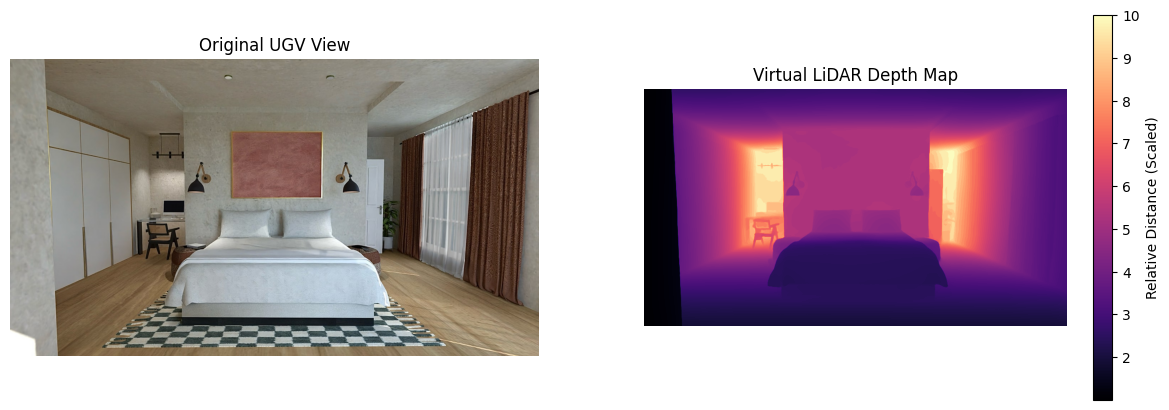

In [121]:
# In Jupyter, we use getcwd() instead of __file__
current_dir = os.getcwd()
image_name = "my_room_2.jpg"
image_full_path = os.path.join(current_dir, image_name)

if os.path.exists(image_full_path):
    # Generate data
    depth_data = generate_virtual_lidar(image_full_path)
    
    # Visualize
    visualize_results(image_full_path, depth_data)
else:
    print(f"Error: Could not find {image_name} in {current_dir}")

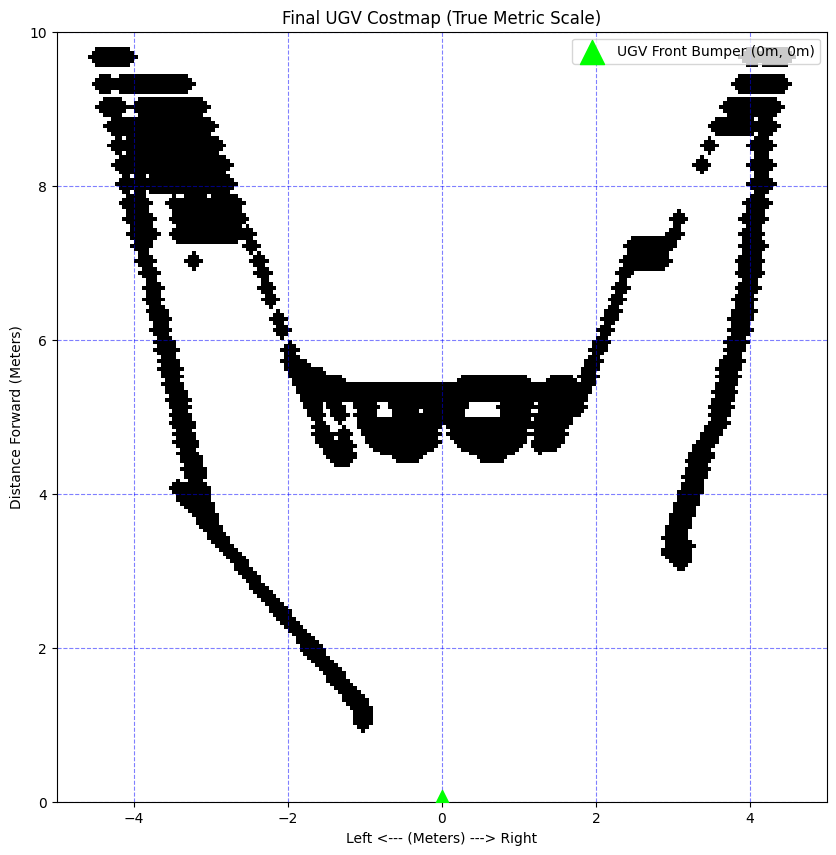

In [124]:
from scipy.ndimage import binary_dilation

fov_val = 90

# Added 'fov' as an adjustable parameter (changed from 90 to 60)
def create_solid_3d_costmap(depth_data, grid_size=(200, 200), max_dist=10.0, fov=fov_val):
    h, w = depth_data.shape
    costmap = np.zeros(grid_size)
    
    f_x = w / (2 * np.tan(np.radians(fov / 2)))
    f_y = f_x 
    center_x = w / 2
    center_y = h / 2

    map_width_m = 10.0 
    map_depth_m = max_dist

    for y in range(0, h, 2): 
        for x in range(0, w, 2):
            z_m = depth_data[y, x]
            
            if z_m <= 0.1 or z_m >= max_dist:
                continue
                
            x_m = (x - center_x) * z_m / f_x
            y_m = (y - center_y) * z_m / f_y 
            
            if -0.4 < y_m < 0.4:
                grid_x = int((x_m / (map_width_m/2)) * (grid_size[1]/2) + (grid_size[1]/2))
                grid_z = int(grid_size[0] - (z_m / map_depth_m) * grid_size[0])
                
                if 0 <= grid_x < grid_size[1] and 0 <= grid_z < grid_size[0]:
                    costmap[grid_z, grid_x] = 1 

    solid_costmap = binary_dilation(costmap, iterations=2).astype(int)
    return solid_costmap

# --- EXECUTION & PROPER VISUALIZATION ---
map_width = 10.0
max_distance = 10.0
binary_map = create_solid_3d_costmap(depth_data, max_dist=max_distance, fov=fov_val)

plt.figure(figsize=(10, 10))

# THE FIX: 'extent' forces the axes to display real physical meters!
# extent format: [x_min, x_max, y_min, y_max]
plt.imshow(binary_map, cmap='Greys', extent=[-map_width/2, map_width/2, 0, max_distance])

# Add the Robot Marker (at X=0m, Y=0m)
plt.scatter(0, 0, color='lime', s=300, marker='^', label='UGV Front Bumper (0m, 0m)', zorder=5)

plt.title("Final UGV Costmap (True Metric Scale)")
plt.xlabel("Left <--- (Meters) ---> Right")
plt.ylabel("Distance Forward (Meters)")

# Add a 1-meter grid to easily judge distances
plt.grid(True, which='both', linestyle='--', alpha=0.5, color='blue')
plt.legend(loc="upper right")
plt.show()

In [125]:
def get_steering_command(binary_map, threshold_area_m2=0.5):
    """
    threshold_area_m2: How many square meters of obstacles we tolerate before turning.
    """
    grid_h, grid_w = binary_map.shape
    
    # 1 pixel = 0.05m x 0.05m = 0.0025 square meters
    pixel_area = 0.0025 
    pixel_threshold = threshold_area_m2 / pixel_area
    
    # Safety Zone: 1m to 4m in front of the robot
    # 1m away = bottom 10% of the map (index 180). 4m away = bottom 40% (index 120)
    safety_zone_top = int(grid_h * 0.6)    
    safety_zone_bottom = int(grid_h * 0.9) 
    
    left_lane = binary_map[safety_zone_top:safety_zone_bottom, :grid_w//3]
    center_lane = binary_map[safety_zone_top:safety_zone_bottom, grid_w//3 : 2*grid_w//3]
    right_lane = binary_map[safety_zone_top:safety_zone_bottom, 2*grid_w//3:]
    
    left_risk = np.sum(left_lane)
    center_risk = np.sum(center_lane)
    right_risk = np.sum(right_lane)
    
    if center_risk < pixel_threshold:
        return "FORWARD ⬆️"
    elif left_risk < right_risk:
        return "STEER LEFT ⬅️"
    else:
        return "STEER RIGHT ➡️"

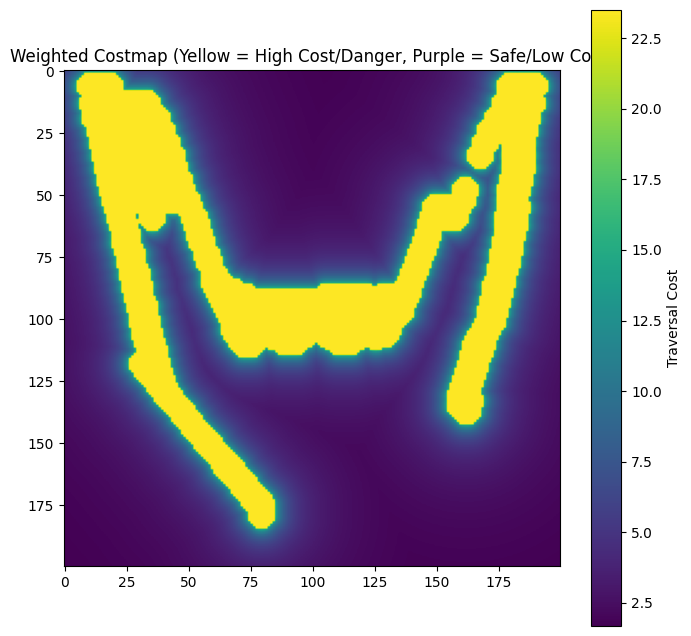

In [126]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt

def create_weighted_costmap(binary_map, safety_radius=4, penalty_weight=50.0):
    """
    Inflates obstacles so the robot doesn't scrape them.
    safety_radius: pixels of absolute padding around objects (lethal zone).
    penalty_weight: how strongly the robot avoids getting near the safety zone.
    """
    # 1. Calculate distance from every free pixel (0) to the nearest obstacle (1)
    # We invert the map because distance_transform_edt measures distance to 0s.
    distances = distance_transform_edt(1 - binary_map)
    
    # 2. Create the new weighted map
    weighted_map = np.zeros_like(binary_map, dtype=float)
    
    # 3. Lethal Zone: If it's inside the safety radius, it's impossible to traverse
    weighted_map[distances < safety_radius] = np.inf
    
    # 4. Penalty Zone: The further away you are, the lower the cost
    safe_mask = distances >= safety_radius
    
    # Base movement cost is 1.0. We add a penalty that decreases as distance increases.
    weighted_map[safe_mask] = 1.0 + (penalty_weight / (distances[safe_mask]))
    
    return weighted_map

# Implementation
weighted_map = create_weighted_costmap(binary_map)

# Quick look at the weighting
plt.figure(figsize=(8, 8))
# We hide 'inf' values for the plot by replacing them with a max value
plot_map = np.copy(weighted_map)
plot_map[plot_map == np.inf] = np.max(plot_map[plot_map != np.inf]) + 10
plt.imshow(plot_map, cmap='viridis', origin='upper')
plt.title("Weighted Costmap (Yellow = High Cost/Danger, Purple = Safe/Low Cost)")
plt.colorbar(label="Traversal Cost")
plt.show()

In [127]:
import heapq

def astar_path(costmap, start, goal):
    """
    Finds the shortest, safest path from start to goal.
    """
    # Helper: Euclidean distance to goal (guides the search)
    def heuristic(a, b):
        return np.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)
    
    # 8 possible directions to move (up, down, left, right, and diagonals)
    neighbors = [(0,1), (0,-1), (1,0), (-1,0), (1,1), (1,-1), (-1,1), (-1,-1)]
    
    # Priority queue stores: (f_score, (y, x))
    open_set = []
    heapq.heappush(open_set, (0, start))
    
    came_from = {}
    g_score = {start: 0} # Cost from start to current node
    
    print("Calculating path... this might take a few seconds.")
    
    while open_set:
        # Get the node with the lowest expected total cost
        _, current = heapq.heappop(open_set)
        
        # If we reached the goal, reconstruct the path!
        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            print("✅ Path successfully found!")
            return path[::-1] # Reverse it so it goes from start to goal
        
        # Check all neighboring pixels
        for dy, dx in neighbors:
            neighbor = (current[0] + dy, current[1] + dx)
            
            # 1. Ensure the neighbor is inside the grid
            if 0 <= neighbor[0] < costmap.shape[0] and 0 <= neighbor[1] < costmap.shape[1]:
                
                # 2. Check if it's a lethal obstacle
                cost = costmap[neighbor]
                if cost == np.inf:
                    continue
                
                # 3. Calculate cost to move there (diagonals cost slightly more: sqrt(2))
                move_cost = np.sqrt(dy**2 + dx**2) * cost
                tentative_g_score = g_score[current] + move_cost
                
                # 4. If this is the best path to this neighbor so far, record it
                if neighbor not in g_score or tentative_g_score < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g_score
                    # f_score = current cost + estimated cost to goal
                    f_score = tentative_g_score + heuristic(neighbor, goal)
                    heapq.heappush(open_set, (f_score, neighbor))
                    
    print("❌ Error: No valid path found to the goal.")
    return []

Calculating path... this might take a few seconds.
✅ Path successfully found!


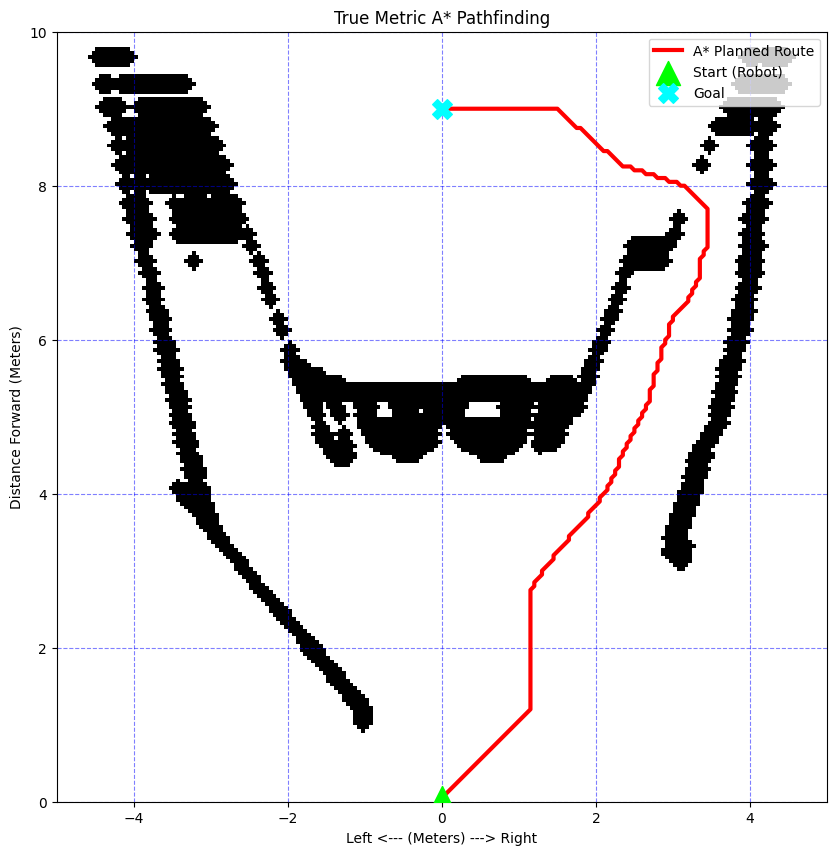

In [128]:
# 1. Define Start and Goal (Using Pixel Indices for the Algorithm)
grid_h, grid_w = weighted_map.shape
start_pos = (grid_h - 1, grid_w // 2) # Robot at bottom center
goal_pos = (20, grid_w // 2)          # Goal near the top center

# 2. Run the algorithm
optimal_path = astar_path(weighted_map, start_pos, goal_pos)

# 3. Plot the results using True Metric Translation
plt.figure(figsize=(10, 10))

map_width = 10.0
max_distance = 10.0

# Plot the map using real meters
plt.imshow(binary_map, cmap='Greys', extent=[-map_width/2, map_width/2, 0, max_distance])

if optimal_path:
    # CONVERSION: Pixel Index -> Real Meters
    # X axis: (pixel / total_pixels) * total_width - half_width
    path_x_meters = [(p[1] / grid_w) * map_width - (map_width / 2) for p in optimal_path]
    
    # Y axis: max_distance - (pixel / total_pixels) * max_distance
    path_y_meters = [max_distance - (p[0] / grid_h) * max_distance for p in optimal_path]
    
    # Plot the converted line
    plt.plot(path_x_meters, path_y_meters, color='red', linewidth=3, label="A* Planned Route")
    
# Convert Start and Goal markers to meters
start_x_m = (start_pos[1] / grid_w) * map_width - (map_width / 2)
start_y_m = max_distance - (start_pos[0] / grid_h) * max_distance

goal_x_m = (goal_pos[1] / grid_w) * map_width - (map_width / 2)
goal_y_m = max_distance - (goal_pos[0] / grid_h) * max_distance

# Draw Markers
plt.scatter(start_x_m, start_y_m, color='lime', s=300, marker='^', label="Start (Robot)", zorder=5)
plt.scatter(goal_x_m, goal_y_m, color='cyan', s=200, marker='X', label="Goal", zorder=5)

plt.title("True Metric A* Pathfinding")
plt.xlabel("Left <--- (Meters) ---> Right")
plt.ylabel("Distance Forward (Meters)")
plt.grid(True, which='both', linestyle='--', alpha=0.5, color='blue')
plt.legend(loc="upper right")
plt.show()